In [49]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=filename, length=len(uploaded[filename])))


# Load Dataset

In [52]:
import os
import numpy as np

labels_path = "/content/drive/MyDrive/Final_project/data/labels.npy"
data_path = "/content/drive/MyDrive/Final_project/data/input_datas.npy"
save_data_path = "/content/drive/MyDrive/Final_project/Output/"

if os.path.exists(f"{save_data_path}dataset.npz"):
    dataset = np.load(f"{save_data_path}dataset.npz")
    labels = dataset['labels']
    data = dataset['data']
else:
    labels = np.load(labels_path)
    data = np.load(data_path)

    assert len(labels) == len(data), "Labels and data should have the same length."

    os.makedirs(save_data_path, exist_ok=True)
    np.savez(f'{save_data_path}dataset.npz', labels=labels, data=data)

print("Data loaded and saved successfully.")
print(f"Labels shape: {labels.shape}")
print(f"Data shape: {data.shape}")

Data loaded and saved successfully.
Labels shape: (351,)
Data shape: (351, 500, 4, 5)


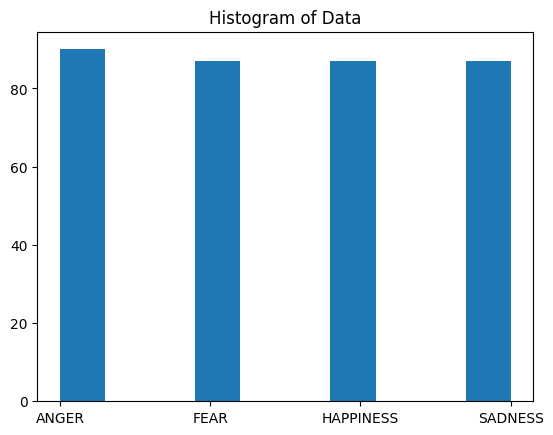

In [53]:
import matplotlib.pyplot as plt

plt.hist(labels, bins='auto')
plt.title('Histogram of Data')  # Title
plt.show()


# Data train

In [54]:
import torch

In [55]:
# Define evaluation function for precision, recall and f1_score
def compute_metrics(true_labels, predicted_labels):

    TP = torch.sum((predicted_labels == 1) & (true_labels == 1)).float()
    FP = torch.sum((predicted_labels == 1) & (true_labels == 0)).float()
    TN = torch.sum((predicted_labels == 0) & (true_labels == 0)).float()
    FN = torch.sum((predicted_labels == 0) & (true_labels == 1)).float()

    # set a very small value (1e-7) to make demon larger than 0
    precision = TP / (TP + FP + 1e-7)
    recall = TP / (TP + FN + 1e-7)
    f1_score = 2 * (precision * recall) / (precision + recall + 1e-7)

    return precision, recall, f1_score

In [56]:
from sklearn.preprocessing import LabelEncoder

# Assuming y_val_fold is a pandas Series or a NumPy array containing string labels
label_encoder = LabelEncoder()
labels_encode = label_encoder.fit_transform(labels)

print(f"The shape of labels_encode is: {labels_encode.shape}")

The shape of labels_encode is: (351,)


In [64]:
# Save label_encoder
import pickle

with open('label_encoder.pkl', 'wb') as file:
    pickle.dump(label_encoder, file)

In [57]:
# split train data and test data
from sklearn.model_selection import train_test_split
import pandas as pd

Xs_train, Xs_test, y_train, y_test = train_test_split(data, labels_encode, test_size=0.2, random_state=1, stratify=labels_encode)
y_train = pd.DataFrame(y_train)

In [58]:
import torch.nn as nn

class CNNetwork(nn.Module):
    def __init__(self, input_shape=(500, 4, 5)):
        super(CNNetwork, self).__init__()

        self.conv1 = nn.Conv2d(4, 8, (3, 3))
        nn.init.kaiming_uniform_(self.conv1.weight, nonlinearity='relu')
        self.batchnorm1 = nn.BatchNorm2d(8)
        self.conv2 = nn.Conv2d(8, 16, (3, 3))
        nn.init.kaiming_uniform_(self.conv2.weight, nonlinearity='relu')
        self.batchnorm2 = nn.BatchNorm2d(16)

        conv_output_shape = self._get_conv_output(input_shape)
        flattened_dim = conv_output_shape[0] * conv_output_shape[1] * conv_output_shape[2]

        self.fc1 = nn.Linear(flattened_dim, 128)
        self.fc2 = nn.Linear(128, 32)
        self.fc3 = nn.Linear(32, 4)

        self.dropout = nn.Dropout(0.5)

    def _get_conv_output(self, shape):
        with torch.no_grad():
            x = torch.rand(1, shape[1], shape[0], shape[2])
            x = F.relu(self.conv1(x), inplace=True)
            x = F.relu(self.conv2(x), inplace=True)
        return x.size()[1:]
    def forward(self, x):
        x = x.permute(0, 2, 1, 3)  # 将输入张量的维度调整为(批次大小, 通道数, 时间戳数, 波的数量)
        x = F.leaky_relu(self.conv1(x))
        x = self.batchnorm1(x)
        x = F.leaky_relu(self.conv2(x))
        x = self.batchnorm2(x)

        x = x.view(x.size(0), -1)  # 扁平化操作

        x = F.leaky_relu(self.fc1(x))
        x = self.dropout(x)
        x = F.leaky_relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        x = x.squeeze(1)  # 移除额外的维度

        return x


In [61]:
# Train model
import torch
import torch.nn.functional as F
from torch.autograd import Variable
import torch.optim as optim
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import KFold

# Initial precision, recall and fi score for evaluation
total_accuracy = []
total_bal_acc = []
total_precision = []
total_recall = []
total_f1 = []

# set batch size to 5
batch_size = 5
# set max epochs to 250
n_max_epochs = 250

# 5-fold cross-validation
kf = KFold(n_splits=5)

for train_idx, val_idx in kf.split(Xs_train):

    #  split datasets
    y_train = y_train.reset_index(drop=True)

    X_train_fold = Xs_train[train_idx]
    X_val_fold = Xs_train[val_idx]
    y_train_fold = y_train.iloc[train_idx]
    y_val_fold = y_train.iloc[val_idx]

    # Convert to pytorch tensors
    X_train_tensor = torch.tensor(X_train_fold).float()
    y_train_tensor = torch.tensor(y_train_fold.to_numpy()).long()
    X_test_tensor = torch.tensor(X_val_fold).float()
    y_test_tensor = torch.tensor(y_val_fold.to_numpy()).long()

    print(f"Shape of y_train_fold: {y_train_fold.shape}")
    print(f"Shape of y_val_fold: {y_val_fold.shape}")

    print(f"Shape of y_train_tensor: {y_train_tensor.shape}")
    print(f"Shape of y_test_tensor: {y_test_tensor.shape}")

    y_train_tensor = y_train_tensor.squeeze(-1)
    y_test_tensor = y_test_tensor.squeeze(-1)

    # Initialize network and optimizer
    net = CNNetwork(input_shape=(500, 4, 5))
    optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.4)

    for epoch in range(n_max_epochs):

        net.train()

        # Initialization
        running_loss = 0.0
        correct_predictions = 0
        total_predictions = 0
        all_labels = []
        all_predictions = []

        for b in range(0, len(X_train_tensor), batch_size):

            if b + batch_size > len(X_train_tensor):
                break

            # Select data for current batch
            inputs = X_train_tensor.narrow(0, b, batch_size)
            labels = y_train_tensor.narrow(0, b, batch_size)
            inputs, labels = Variable(inputs), Variable(labels)

            optimizer.zero_grad() # Reset the gradients
            outputs = net(inputs) # Predicted outputs
            loss = F.cross_entropy(outputs, labels) # Calculate the loss using cross entropy loss function
            loss.backward() # perform backpropagation
            optimizer.step() # Update parameters

            # Running loss accumulation
            running_loss += loss.item()

            # Caculate number of correct predicted labels
            _, predicted = torch.max(outputs.data, 1)
            total_predictions += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

            # Append true labels into all_labels
            all_labels.extend(labels.tolist())
            # Append predicted labels into all_predictions
            all_predictions.extend(predicted.tolist())


        # Calculate and print epoch accuracy
        epoch_accuracy = 100 * correct_predictions / total_predictions
        print(f"Epoch {epoch}, Loss: {running_loss}, Accuracy: {epoch_accuracy}%")

        # Calculate and print epoch balanced Classification accuracy
        balanced_acc = balanced_accuracy_score(all_labels, all_predictions)
        print(f"Epoch {epoch}, Loss: {running_loss}, Balanced Accuracy: {balanced_acc * 100}%")

    # Test model in test dataset
    net.eval()
    test_outputs = net(X_test_tensor)
    _, predicted = torch.max(test_outputs.data, 1)

    # Calculate and precision, recoall and fi score
    precision, recall, f1 = compute_metrics(y_test_tensor, predicted)

    # Calculate accuracy in test data
    correct = (predicted == y_test_tensor).sum().item()
    accuracy = 100 * correct / len(y_test_tensor)

    # Calculate balanced_accuracy in test data
    test_balanced_acc = balanced_accuracy_score(y_test_tensor.tolist(), predicted.tolist())

    # Print test results
    print(f"Test Accuracy: {accuracy}%")
    print(f"Test Balanced Accuracy: {test_balanced_acc * 100}%")
    print('Test precision: {:.2f}%'.format(precision*100))
    print('Test recall: {:.2f}%'.format(recall*100))
    print('Test F1 score: {:.2f}%'.format(f1*100))

    # Append results
    total_accuracy.append(accuracy)
    total_bal_acc.append(test_balanced_acc)
    total_precision.append(precision)
    total_recall.append(recall)
    total_f1.append(f1)

# Save MLPNetwork
torch.save(net.state_dict(), 'PCR_mpl_net.pth')

Shape of y_train_fold: (224, 1)
Shape of y_val_fold: (56, 1)
Shape of y_train_tensor: torch.Size([224, 1])
Shape of y_test_tensor: torch.Size([56, 1])
Epoch 0, Loss: 62.51041769981384, Accuracy: 19.545454545454547%
Epoch 0, Loss: 62.51041769981384, Balanced Accuracy: 20.196377472406528%
Epoch 1, Loss: 60.630258083343506, Accuracy: 27.727272727272727%
Epoch 1, Loss: 60.630258083343506, Balanced Accuracy: 28.551008271283536%
Epoch 2, Loss: 59.87159991264343, Accuracy: 32.27272727272727%
Epoch 2, Loss: 59.87159991264343, Balanced Accuracy: 32.83106235763302%
Epoch 3, Loss: 58.50589609146118, Accuracy: 35.90909090909091%
Epoch 3, Loss: 58.50589609146118, Balanced Accuracy: 36.65110663517698%
Epoch 4, Loss: 58.975645422935486, Accuracy: 38.18181818181818%
Epoch 4, Loss: 58.975645422935486, Balanced Accuracy: 38.4655342957879%
Epoch 5, Loss: 56.497634410858154, Accuracy: 45.0%
Epoch 5, Loss: 56.497634410858154, Balanced Accuracy: 45.09086661183004%
Epoch 6, Loss: 56.808409452438354, Accuracy

In [62]:
# Calculate the averages of MLPNetwork
avg_accuracy = np.mean(total_accuracy)
avg_bal_acc = np.mean(total_bal_acc)
avg_precision = np.mean(total_precision)
avg_recall = np.mean(total_recall)
avg_f1 = np.mean(total_f1)

print(f"Average Accuracy: {avg_accuracy}")
print(f"Average Balanced Accuracy: {avg_bal_acc}")
print(f"Average Precision: {avg_precision}")
print(f"Average Recall: {avg_recall}")
print(f"Average F1 Score: {avg_f1}")

Average Accuracy: 26.428571428571427
Average Balanced Accuracy: 0.26526506173565
Average Precision: 0.4517948627471924
Average Recall: 0.5750000476837158
Average F1 Score: 0.4995554983615875
